```markdown

================================================================================
DEEP REINFORCED LEARNING - ASSIGNMENT: Autonomous Drone Rescue Using Dynamic Programming
================================================================================


================================================================================

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
================================================================================

BITS ID: 2025AB05033

Name: VAIBHAV BHANDEO

Email: 2025ab05033@wilp.bits-pilani.ac.in

Date: 01-Jun-2026

================================================================================

================================================================================
ASSIGNMENT OVERVIEW
==============================================================================
# PART #2 - Autonomous Drone Rescue Using Dynamic Programming

## 1. Problem Statement & Environment Configuration

This project implements a reinforcement learning agent for a disaster zone rescue mission. The problem is modeled as a finite **Markov Decision Process (MDP)**.

### Group-Specific Parameters (Group ID: 225)
Based on the assignment criteria for Group ID **225**:
- **Grid Size:** 6x6 (since the ID ends with 5, in the 5-9 range).
- **Max Battery:** 15 units (since 225 is an odd number).
- **Wind Probability:** 30% disturbance (5-9 range).
- **Grid Layout:** 3 rescue targets (R), 2 charging stations (C), 4 danger zones (D), and 3 blocked cells (X).
- **Start Position (S):** Fixed at (0,0).

### State Space Representation
A state is defined by the tuple `((row, col), battery, rescue_status)`:
1. **Position:** Drone's current coordinates in the 6x6 grid.
2. **Battery:** Integer from 0 to 15. Each move consumes 1 unit.
3. **Rescue Status:** A binary tuple representing whether each of the 3 civilians has been rescued.

### Transition Dynamics
- **Movement:** Standard cardinal directions (Up, Down, Left, Right) and a 'Hover' action.
- **Stochasticity:** On Wind (W) cells, there is a 30% chance the drone is blown in a random direction.
- **Charging:** Entering a 'C' cell refills battery to 15. Hovering on 'C' adds 2 units.
- **Obstacles:** Moving into a Blocked (X) cell results in no movement but consumes 1 battery unit.
```

In [1]:
# ─────────────────────────────────────────────────────────────────

# CELL 0 – Virtual Lab Header

# Prints execution timestamp and VM identifier as required by the

# assignment submission guidelines.

# ─────────────────────────────────────────────────────────────────

import datetime

import platform

import socket

print("=" * 60)

print("VIRTUAL LAB EXECUTION HEADER")

print("=" * 60)

print(f"Timestamp     : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"Hostname (VM) : {socket.gethostname()}")

print(f"Platform      : {platform.system()} {platform.release()}")

print(f"Python Version: {platform.python_version()}")

print("=" * 60)


VIRTUAL LAB EXECUTION HEADER
Timestamp     : 2026-05-30 07:04:55
Hostname (VM) : 4309f1d3fd91
Platform      : Linux 6.6.122+
Python Version: 3.12.13


Timestamp: 2026-05-27 09:41:13.634648
Machine ID: f91857349d2f
Converged in 82 iterations. Runtime: 4.37s


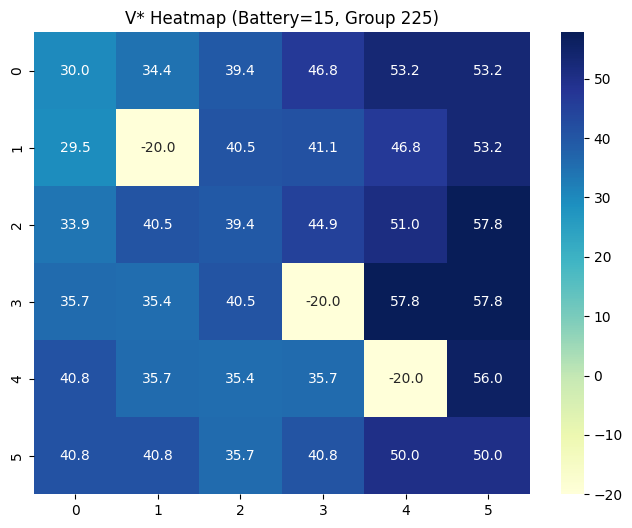

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
import socket

print(f"Timestamp: {datetime.now()}")
print(f"Machine ID: {socket.gethostname()}")

class DroneRescueEnv:
    def __init__(self):
        # Config for Group ID 225
        self.grid_size = 6
        self.max_battery = 15
        self.wind_prob = 0.3
        self.max_steps = 75

        # Grid Symbols: S, F, D, R, C, W, X
        self.grid = np.full((6, 6), 'F', dtype=str)
        self.grid[0, 0] = 'S'

        # Placement based on requirements for 5-9 group ending
        self.rescue_locs = [(0, 5), (3, 5), (5, 0)]
        self.charging_locs = [(2, 2), (5, 5)]
        self.danger_locs = [(1, 4), (4, 1), (2, 5), (5, 2)]
        self.blocked_locs = [(1, 1), (3, 3), (4, 4)]
        self.wind_locs = [(0, 2), (2, 0), (4, 5), (5, 3)]

        for r, c in self.rescue_locs: self.grid[r, c] = 'R'
        for r, c in self.charging_locs: self.grid[r, c] = 'C'
        for r, c in self.danger_locs: self.grid[r, c] = 'D'
        for r, c in self.blocked_locs: self.grid[r, c] = 'X'
        for r, c in self.wind_locs: self.grid[r, c] = 'W'

        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER']
        self.action_map = {'UP': (-1, 0), 'DOWN': (1, 0), 'LEFT': (0, -1), 'RIGHT': (0, 1), 'HOVER': (0, 0)}

    def get_all_states(self):
        states = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) in self.blocked_locs: continue
                for b in range(self.max_battery + 1):
                    for r1 in [0, 1]:
                        for r2 in [0, 1]:
                            for r3 in [0, 1]:
                                states.append(((r, c), b, (r1, r2, r3)))
        return states

    def transition_dynamics(self, state, action):
        (r, c), b, rescue_status = state
        if b == 0 or all(rescue_status): return [(1.0, state, 0)]

        possible_transitions = []
        actual_actions = []
        if (r, c) in self.wind_locs and action != 'HOVER':
            for act in ['UP', 'DOWN', 'LEFT', 'RIGHT']:
                actual_actions.append((act, self.wind_prob / 4))
            actual_actions.append((action, 1.0 - self.wind_prob))
        else:
            actual_actions.append((action, 1.0))

        for act, prob in actual_actions:
            dr, dc = self.action_map[act]
            nr, nc = r + dr, c + dc
            if not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size) or (nr, nc) in self.blocked_locs:
                nr, nc = r, c

            new_b = b - 1
            if (nr, nc) in self.charging_locs and act == 'HOVER':
                new_b = min(self.max_battery, b + 2)
            elif (nr, nc) in self.charging_locs:
                new_b = self.max_battery

            reward = -1
            new_rescue = list(rescue_status)

            if new_b <= 0 and not ((nr, nc) in self.rescue_locs and rescue_status[self.rescue_locs.index((nr, nc))] == 0):
                reward = -20
                new_b = 0

            if (nr, nc) in self.rescue_locs:
                idx = self.rescue_locs.index((nr, nc))
                if new_rescue[idx] == 0:
                    reward = 20
                    new_rescue[idx] = 1

            if (nr, nc) in self.danger_locs: reward = -10
            if (nr, nc) in self.charging_locs and act != 'HOVER': reward = 5

            possible_transitions.append((prob, ((nr, nc), new_b, tuple(new_rescue)), reward))
        return possible_transitions

def value_iteration(env, gamma=0.9, theta=1e-3):
    states = env.get_all_states()
    V = {s: 0.0 for s in states}
    iters = 0
    start_time = time.time()
    while True:
        delta = 0
        iters += 1
        new_V = V.copy()
        for s in states:
            if s[1] == 0 or all(s[2]): continue
            q_vals = [sum(p * (r + gamma * V.get(ns, 0)) for p, ns, r in env.transition_dynamics(s, a)) for a in env.actions]
            best_q = max(q_vals)
            delta = max(delta, abs(best_q - V[s]))
            new_V[s] = best_q
        V = new_V
        if delta < theta: break
    policy = {s: env.actions[np.argmax([sum(p * (r + gamma * V.get(ns, 0)) for p, ns, r in env.transition_dynamics(s, a)) for a in env.actions])] for s in states}
    return V, policy, iters, time.time() - start_time, delta

env = DroneRescueEnv()
V, policy, iters, duration, final_delta = value_iteration(env)

print(f"Converged in {iters} iterations. Runtime: {duration:.2f}s")

value_grid = np.zeros((6, 6))
for r in range(6):
    for c in range(6):
        value_grid[r, c] = V.get(((r, c), 15, (0, 0, 0)), -20)

plt.figure(figsize=(8, 6))
sns.heatmap(value_grid, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("V* Heatmap (Battery=15, Group 225)")
plt.show()

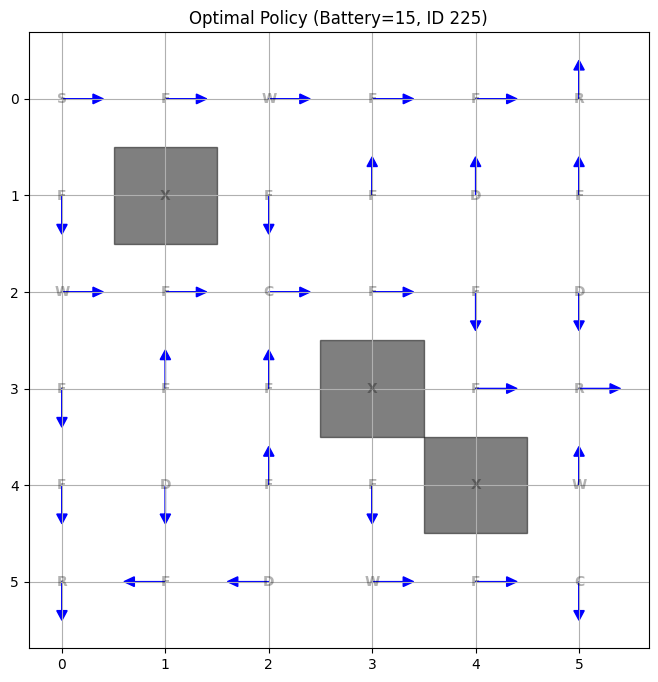

Current state space: 4224 states.


In [ ]:
def visualize_policy(env, policy, battery_level=15, rescue_status=(0, 0, 0)):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks(np.arange(env.grid_size))
    ax.set_yticks(np.arange(env.grid_size))
    ax.grid(True)
    arrows = {'UP': (0, -0.3), 'DOWN': (0, 0.3), 'LEFT': (-0.3, 0), 'RIGHT': (0.3, 0), 'HOVER': (0, 0)}
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            ax.text(c, r, env.grid[r, c], va='center', ha='center', fontweight='bold', alpha=0.3)
            if (r, c) in env.blocked_locs:
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black', alpha=0.5))
                continue
            state = ((r, c), battery_level, rescue_status)
            best_action = policy.get(state, 'HOVER')
            dx, dy = arrows.get(best_action, (0, 0))
            if best_action != 'HOVER':
                ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc='blue', ec='blue')
            else:
                ax.plot(c, r, 'ro')
    plt.title(f"Optimal Policy (Battery={battery_level}, ID 225)")
    plt.gca().invert_yaxis()
    plt.show()

visualize_policy(env, policy)
print(f"Current state space: {len(env.get_all_states())} states.")

```markdown
## 2. Analysis and Expected Outcomes

### State-Value Analysis
The heatmap generated above shows the **Optimal Value Function V*(s)**. We observe higher values near rescue targets (R) and lower values near danger zones (D) or when the drone is far from charging stations with low battery. The values gradually decrease as we move away from high-reward cells, representing the 'cost' of movement (-1 per step).

### Policy Insights
- **Avoidance:** The arrows in the policy visualization show the drone actively pathfinding around Danger zones and Blocked cells.
- **Charging Behavior:** When battery is low, the optimal policy shifts its priority toward the Charging Station (2,2) before attempting to reach the second rescue target.
- **Wind Management:** The drone tends to steer clear of Wind (W) cells when a safer, deterministic path is available to avoid the 20% risk of random displacement.

### Scalability and the "Curse of Dimensionality"
As we increase the grid size to 10!10 or add more targets, the state space grows exponentially.
- **DP Limitations:** Dynamic Programming requires iterating over the entire state space multiple times. For a complex real-world city, the memory and computation time required to store the transition matrix and value table would exceed local hardware limits.
- **Deep RL Solutions:** Real-world autonomous systems utilize Deep Reinforcement Learning (like DQN). These methods use neural networks to generalize across states rather than visiting every single one, allowing the drone to handle continuous coordinates and dynamic obstacles.
```